Montare una cartella in Google Colab significa creare una connessione tra il tuo ambiente di lavoro su Colab e una cartella di Google Drive. Questo ti consente di accedere ai file in quella cartella direttamente da Colab e di salvare i risultati o i modelli generati durante il tuo lavoro.


In [1]:
from google.colab import drive
mount_path = '/content/drive'
drive.mount(mount_path)
save_path = mount_path +'/MyDrive/Colab_Images/Intro_AI_24-25/'

Mounted at /content/drive


#CNN Layers (Encoders)

https://keras.io/api/


![CNN_Layers](https://drive.google.com/uc?id=1wF8ivQk6ucQyol9xOMTUL4CR68ctA4ux)






*   Le reti neurali convoluzionali (CNN) sono ampiamente utilizzate nell'ambito del deep learning per il riconoscimento di pattern in immagini.

*   Il layer convoluzionale utilizza un insieme di filtri (o kernel) per eseguire la convoluzione sull'input. Questi filtri sono matrici di pesi che vengono appresi durante l'addestramento del modello.

*  Il filtro scorre sull'input attraverso una finestra (spesso di dimensioni 3x3 o 5x5), eseguendo la moltiplicazione elemento per elemento con i valori corrispondenti nell'input.

*   Dopo la convoluzione, solitamente viene applicata una funzione di attivazione, come la funzione ReLU (Rectified Linear Unit), per introdurre la non linearità nella rete.

*   L'output viene appiattito in un vettore unidimensionale, pronto per essere utilizzato come input per i layer successivi connessi.

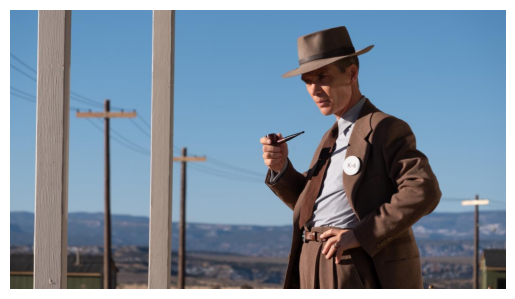

dimensioni dell'immagine: (675, 1200, 3)


In [2]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt

#Scarichiamo un immagine da un link drive
url="https://drive.google.com/uc?id=1oMwhUwK-tuCaAP-_2aiTyoCrLIcqkDc9"
img = imageio.imread(url) #usiamo un array Numpy per rappresentare l'immagine in RGB

# Visualizza l'immagine con Matplotlib
plt.imshow(img)
plt.axis('off')  # Nasconde gli assi
plt.show()
#Stampiamo alcune caratteristiche dell'immagine.
print(f"dimensioni dell'immagine: {img.shape}")  # (altezza x larghezza x canali)

###Convoluzione
- Conv2D

In [3]:
from keras.layers import Conv2D

batch_size = 1
height = img.shape[0]
width = img.shape[1]
channels = img.shape[2]

print( f"height = {height}" )
print( f"width = {width}" )
print( f"channels = {channels}" )


input_img =  img.reshape(batch_size, height, width, channels).astype(float) / 255.0


print( f"Img shape: {input_img.shape}")

output = Conv2D(
      filters=1,                    # The number of filters
      kernel_size=(3, 3),           # Height and width of the 2D Convolution window.
      strides=(1, 1),               # (Height,width)
      padding="valid",              # "same" per renderlo della stessa dimensione dell'output
      dilation_rate=(1, 1),         # serve ad allargare il campo visivo del kernel
      groups=1,                     # channels e filtri devono essere divisibili per il numero dei gruppi, gruppi non possono essere piu grandi dei channels

      activation='relu',
      use_bias=True,                # bias pure qui ovviamente
      kernel_initializer="uniform",
      bias_initializer="zeros",
      kernel_regularizer=None,
      bias_regularizer=None,
      activity_regularizer=None,
      kernel_constraint=None,
      bias_constraint=None,

    )(input_img)

print(f"Output shape: {output.shape}")

# Formula su ogni asse.
# ouput = ([input - kernel + (2xpadding)]/stride ) + 1
# 673 = (675 - 3 + 2*0 )/1 + 1
# 1198 = (1200 - 3 + 2*0)/1 + 1

height = 675
width = 1200
channels = 3
Img shape: (1, 675, 1200, 3)
Output shape: (1, 673, 1198, 1)


Attenzione ogni filtro viene applicato su ogni canale e poi i risultati ottenuti vengono sommati. Keras gestisce questa operazione.

### Pooling Layers

1.  MaxPoolingLayer
2.  AveragePoolingLayer

![MaxPooling](https://drive.google.com/uc?id=1jNe2MhWwqbRFyTOhnyRQ61JJVSFbzHL6 )

In [4]:
import numpy as np
from keras.models import Sequential
from keras.layers import MaxPooling2D, AveragePooling2D

# Definizione dell'input
input_data = np.array([[[1, 2, 3, 4],
                        [5, 6, 7, 8],
                        [9, 10, 11, 12],
                        [13, 14, 15, 16]]], dtype=np.float32)

# Reshape dell'input per adattarlo al formato richiesto dai modelli
input_data = np.reshape(input_data, (1, 4, 4, 1))

# Creazione del modello con MaxPooling2D
model_max_pooling = Sequential()
model_max_pooling.add(MaxPooling2D(pool_size=(2, 2)))

# Creazione del modello con AveragePooling2D
model_avg_pooling = Sequential()
model_avg_pooling.add(AveragePooling2D(pool_size=(2, 2)))


# Applicazione dei modelli all'input
output_max_pooling = model_max_pooling.predict(input_data)
output_avg_pooling = model_avg_pooling.predict(input_data)
# Stampa dell'input
print("Input:")
print(input_data.squeeze())

# Stampare i risultati
print("\nRisultato con Max Pooling:")
print(output_max_pooling.squeeze())

print("\nRisultato con Average Pooling:")
print(output_avg_pooling.squeeze())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Input:
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

Risultato con Max Pooling:
[[ 6.  8.]
 [14. 16.]]

Risultato con Average Pooling:
[[ 3.5  5.5]
 [11.5 13.5]]


#Image classification

### Importiamo il dataset

In [5]:
from keras.datasets import cifar10
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Classi Cifrar-10:
1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck






classe: [2]


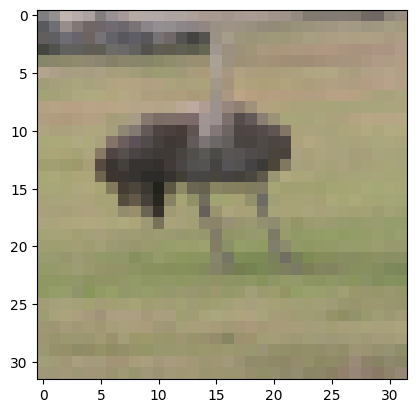

In [6]:
plt.imshow(X_train[42])
print(f'classe: {Y_train[42]}')

### Pre-processing data

In [7]:

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train,stratify=Y_train, test_size = 0.2,shuffle = True)

In [9]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoder.fit(Y_train)
Y_train = encoder.transform(Y_train).toarray()
Y_test = encoder.transform(Y_test).toarray()
Y_val =  encoder.transform(Y_val).toarray()

In [10]:
import tensorflow as tf
img_gen = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.05,
                             height_shift_range=0.05,horizontal_flip=True
)
img_gen.fit(X_train)

### Iperparametri

In [11]:
learningrate=1e-3
momentum=0.8
batch_size=256
epochs=20

# ResNet-50 (Residual Network)

**ResNet**  è un'architettura proposta da He et al. nel 2015, che ha rivoluzionato il deep learning introducendo i residual blocks. Questi blocchi permettono di allenare reti molto profonde (oltre 100 layer) risolvendo il problema del vanishing gradient.

Normalmente, in una rete, ogni layer cerca di imparare una mappatura complessa tra **input** e **output**. Tuttavia, quando la rete è molto profonda, diventa difficile ottimizzare questa mappatura perché i gradienti tendono a diminuire drasticamente, rendendo l'apprendimento inefficace.

Il **residual block** affronta questo problema introducendo una scorciatoia, nota come skip connection, che permette all'input originale di bypassare i layer intermedi e arrivare direttamente all'output.

# Residual Block

![Residual-Block](https://drive.google.com/uc?id=1RsQPFg_jGJoPi9ZJmh9yTimbyyCf_Om_)


In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

def create_resnet50_model(input_shape=(32, 32, 3), num_classes=10):

    # Base ResNet50 pre-addestrata su ImageNet
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Costruzione del classificatore
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs)  # Uso del modello base senza addestramento
    x = layers.GlobalAveragePooling2D()(x)  # Pooling globale
    x = layers.Dense(256, activation='relu')(x)  # Fully connected
    x = layers.Dropout(0.5)(x)  # Dropout per regolarizzazione
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # Layer di output

    # Modello completo
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import plot_model

# Carica il modello ResNet50 preaddestrato
model = create_resnet50_model()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
import keras
model.build(input_shape = (None,32,32,3))
#use categorical_crossentropy since the label is one-hot encoded
model.compile(optimizer = keras.optimizers.SGD(learning_rate=learningrate, momentum=momentum),loss='categorical_crossentropy', metrics=["accuracy"])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 1, 1, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [15]:
try:
    model.load_weights(save_path + '/pesi_resnet_v1.weights.h5')
    epochs=0
    loaded=True
    print("Pesi modello caricati")
except Exception as e:
    print(f"No weights loaded:\n{e}")
    loaded=False

No weights loaded:
[Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/Colab_Images/Intro_AI_24-25//pesi_resnet_v1.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


In [16]:
history = model.fit(img_gen.flow(X_train,Y_train,batch_size = batch_size),
                    batch_size = batch_size,
                    epochs=epochs,
                    validation_data=(X_val, Y_val))

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 103s 376ms/step - accuracy: 0.1474 - loss: 3.0913 - val_accuracy: 0.1000 - val_loss: 47.5910
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - accuracy: 0.3173 - loss: 1.9405 - val_accuracy: 0.1000 - val_loss: 21.7151
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.4802 - loss: 1.5258 - val_accuracy: 0.1076 - val_loss: 11.0168
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 179ms/step - accuracy: 0.5607 - loss: 1.2855 - val_accuracy: 0.1446 - val_loss: 2.9932
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accuracy: 0.6221 - loss: 1.1183 - val_accuracy: 0.3143 - val_loss: 2.1615
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - accuracy: 0.6526 - loss: 1.0133 - val_accuracy: 0.5416 - val_loss: 1.3196
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.6814 - loss: 0.9470 - val_accuracy: 0.6934 - val_loss: 0.8953
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 178ms/step - accuracy: 0.7098 - loss: 0.8663 -

In [17]:
model.save_weights('./pesi_resnet.weights.h5')

### Training curves

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


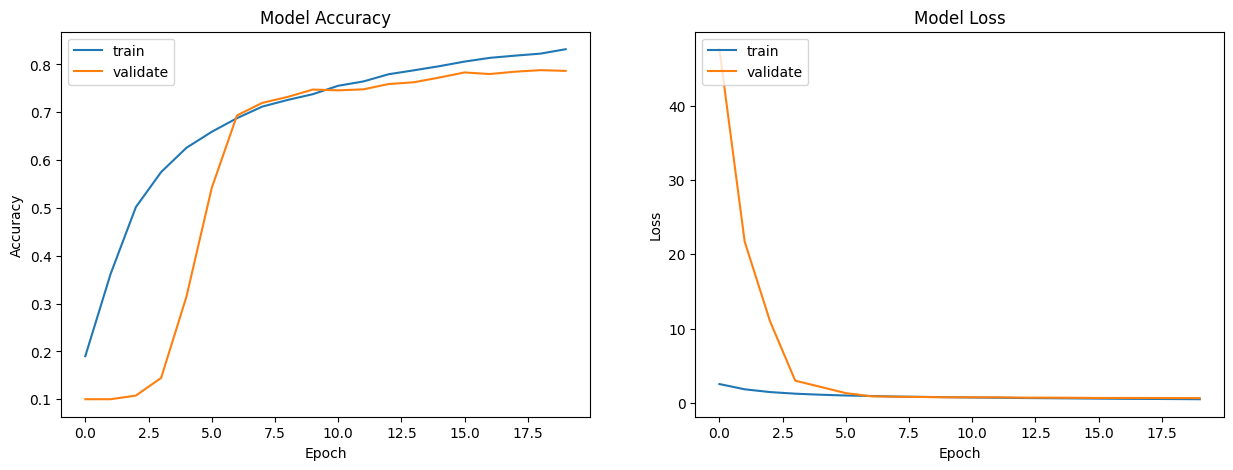

In [18]:
def plotmodelhistory(history):
    fig, axs = plt.subplots(1,2,figsize=(15,5))
    # summarize history for accuracy
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')

    axs[0].legend(['train', 'validate'], loc='upper left')
    # summarize history for loss
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['train', 'validate'], loc='upper left')
    plt.show()

if not loaded:
  # list all data in history
  print(history.history.keys())
  plotmodelhistory(history)

In [19]:

ModelLoss, ModelAccuracy = model.evaluate(X_test, Y_test)

print('Model Loss is {}'.format(ModelLoss))
print('Model Accuracy is {}'.format(ModelAccuracy))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7807 - loss: 0.6805
Model Loss is 0.6763579845428467
Model Accuracy is 0.7828999757766724


link all'esempio completo https://www.kaggle.com/code/songrise/implementing-resnet-18-using-keras/notebook

##UpSampling layers (Decoders)


In [20]:
import numpy as np
from keras.models import Sequential
from keras.layers import UpSampling2D

# Definizione dell'input
input_data = np.array([[[1, 2],
                        [3, 4]]], dtype=np.float32)

# Reshape dell'input aggiungo channels e batch size
input_data = np.reshape(input_data, (1, 2, 2, 1))

# Creazione del modello con UpSampling2D
model_upsampling = Sequential()
model_upsampling.add(UpSampling2D(size=(2, 2), interpolation="nearest"))
#options are: "nearest" (default), "area", "bicubic", "bilinear", "gaussian", "lanczos3", "lanczos5", "mitchellcubic"
model_upsampling.build(input_data.shape)

model_upsampling.summary()

# Applicazione del modello all'input
output_upsampling = model_upsampling.predict(input_data)

# Stampa dell'input
print("Input:")
print(input_data.squeeze())

# Stampare i risultati
print("\nRisultato con UpSampling:")
print(output_upsampling.squeeze())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ up_sampling2d (UpSampling2D)         │ (1, 4, 4, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Input:
[[1. 2.]
 [3. 4.]]

Risultato con UpSampling:
[[1. 1. 2. 2.]
 [1. 1. 2. 2.]
 [3. 3. 4. 4.]
 [3. 3. 4. 4.]]


Questo layer tuttavia non apprende nulla per questo è tipicamente usato fra i layer convoluzionali.



##Conv2DTranspose layer (Decoders)

[Alcuni esempi qui](https://calvinfeng.gitbook.io/machine-learning-notebook/supervised-learning/convolutional-neural-network/transpose_convolution_operation)

![Conv2DTranspose](https://drive.google.com/uc?id=1zkPpDEAWzN-jlyiQRzGNBD-s-XtkYL0J )


In [21]:
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2DTranspose

# Definizione dell'input
input_data = np.array([[[1, 2],
                        [3, 4]]], dtype=np.float32)

# Reshape dell'input per adattarlo al formato richiesto dai modelli
input_data = np.reshape(input_data, (1, 2, 2, 1))

# Creazione del modello con Conv2DTranspose
model_transpose_conv = Sequential()
model_transpose_conv.add(Conv2DTranspose(filters=1, kernel_size=(3, 3), strides=(2, 2), padding='same', input_shape=(2, 2, 1)))

# Compilazione del modello
model_transpose_conv.compile(optimizer='adam', loss='mean_squared_error')

# Stampa dell'input
print("Input:")
print(input_data.squeeze())

# Stampa del modello
model_transpose_conv.summary()

# Applicazione del modello all'input
output_transpose_conv = model_transpose_conv.predict(input_data)

# Stampare i risultati
print("\nRisultato con Transpose Convolution:")
print(output_transpose_conv.squeeze())


Input:
[[1. 2.]
 [3. 4.]]


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose (Conv2DTranspose)   │ (None, 4, 4, 1)             │              10 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step

Risultato con Transpose Convolution:
[[-0.128156    0.4119221  -0.29042274  0.8238442 ]
 [-0.25688848 -0.28651813 -0.73148966 -0.57303625]
 [-0.33742166  1.7879149  -0.85273147  2.7519855 ]
 [-0.7706654  -0.8595544  -1.6806921  -1.1460725 ]]


#Image segmentation

Assegna una "classe" ad ogni pixel dell'immagine.

Con questo approccio, ad esempio puoi:
- sapere la shape dell'oggetto contenuto nell'immagine.
- se un pixel appartiene all'oggetto.
- Estrarre informazioni a livello di pixel.

I task di image segmentation trovano applicazione nelle immagini provenienti dalla guida autonoma, imagini mediche o dei satelliti..

![Image Segmentation](https://drive.google.com/uc?id=1xO189Tlv8GbE86sncajEn6LmkE3NTu6l )


## Dataset


Questo esempio usa il **Dataset Oxford-IIIT Pet** (Parkhi et al, 2012)
Il dataset possiede immagini di 37 animali domestisci (cani e gatti) e ci sono circa 200 immagini per tipo di animale.

Per ogni immagine ci sono delle ground truth:
- label del tipo di animale domestico
- una maschera pixel-wise dove ogni pixel può assumere i valori di:
  *   1 se il pixel appartiene all'animale.
  *   2 se il pixel è del bordo
  *   3 se il pixel è background.


In [22]:
!pip install keras_cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 46.4 MB/s eta 0:00:00


Lanciamo il comando per installare keras_cv e poi importiamo le librerie.

In [23]:
import random
import keras
import keras_cv
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from matplotlib import pyplot as plt

Iperparametri

In [24]:
# Image Config
HEIGHT = 24
WIDTH = 24
NUM_CLASSES = 3
#AUTOTUNE = tf.data.AUTOTUNE #ottimizza in automatico le prestazioni sulla base dell'hw

# Training Config
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3

**Download del dataset.**

Scarichiamo il dataset Oxford-IIT Pet con il modulo TFDS (tensorflow-datasets)

Combiniamo training e test set insieme e poi li splittiamo in 80% training e 20% test. Nello splitting originale, hanno circa la stessa dimensione. Useremo lo splitting del 20% sia come validation e che testing set.


In [25]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!
!gunzip images.tar.gz
!gunzip annotations.tar.gz
!
!tar -xf images.tar
!tar -xf annotations.tar



--2024-12-02 10:06:18--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2024-12-02 10:06:19--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  17.1MB/s    in 32s     

2024-12-02 10:06:52 (23.4 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2024-12-02 10:06:52--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

Data preprocessing

Link alla documentazione: https://www.tensorflow.org/datasets/catalog/oxford_iiit_pet

In [26]:
import os

input_dir = "images/"
target_dir = "annotations/trimaps/"
img_size = (160, 160)
num_classes = 3
batch_size = 32

input_img_paths = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname)
        for fname in os.listdir(target_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Number of samples:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Number of samples: 7390
images/Abyssinian_1.jpg | annotations/trimaps/Abyssinian_1.png
images/Abyssinian_10.jpg | annotations/trimaps/Abyssinian_10.png
images/Abyssinian_100.jpg | annotations/trimaps/Abyssinian_100.png
images/Abyssinian_101.jpg | annotations/trimaps/Abyssinian_101.png
images/Abyssinian_102.jpg | annotations/trimaps/Abyssinian_102.png
images/Abyssinian_103.jpg | annotations/trimaps/Abyssinian_103.png
images/Abyssinian_104.jpg | annotations/trimaps/Abyssinian_104.png
images/Abyssinian_105.jpg | annotations/trimaps/Abyssinian_105.png
images/Abyssinian_106.jpg | annotations/trimaps/Abyssinian_106.png
images/Abyssinian_107.jpg | annotations/trimaps/Abyssinian_107.png


In [27]:
import random


# Define the split ratio (e.g., 80% train, 20% test)
split_ratio = 0.8

# Calculate the split index
split_index = int(len(input_img_paths) * split_ratio)

# Create a list of indices for all samples
indices = list(range(len(input_img_paths)))

# Shuffle the indices randomly
random.shuffle(indices)

# Split the indices into training and testing sets
train_indices = indices[:split_index]
test_indices = indices[split_index:]

# Create the training and testing datasets using the indices
x_train = [input_img_paths[i] for i in train_indices]
y_train = [target_img_paths[i] for i in train_indices]
x_test = [input_img_paths[i] for i in test_indices]
y_test = [target_img_paths[i] for i in test_indices]

print("Number of training samples:", len(x_train))
print("Number of testing samples:", len(x_test))

Number of training samples: 5912
Number of testing samples: 1478


Visualizziamo alcune immagini

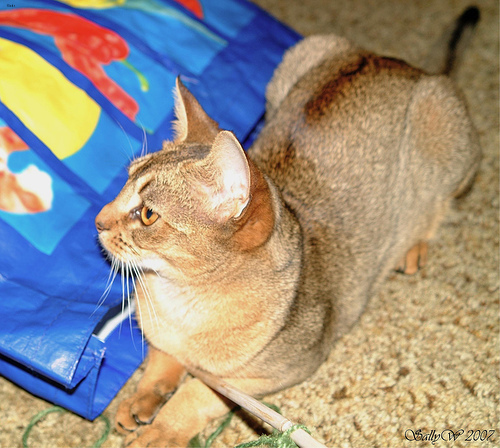

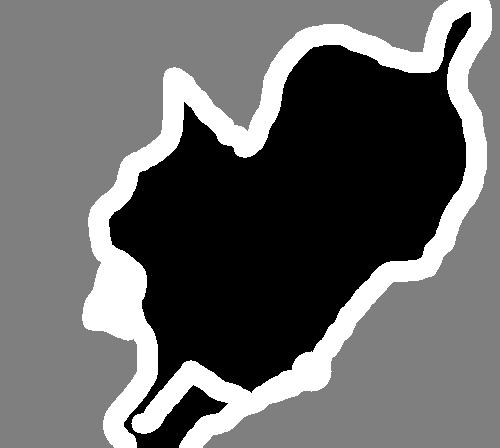

In [28]:
from IPython.display import Image, display
from keras.utils import load_img
from PIL import ImageOps

# Display input image #7
display(Image(filename=input_img_paths[9]))

# Display auto-contrast version of corresponding target (per-pixel categories)
img = ImageOps.autocontrast(load_img(target_img_paths[9]))
display(img)

In [29]:
import keras
import numpy as np
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow import io as tf_io


def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""

    def load_img_masks(input_img_path, target_img_path):
        input_img = tf_io.read_file(input_img_path)
        input_img = tf_io.decode_png(input_img, channels=3)
        input_img = tf_image.resize(input_img, img_size)
        #input_img = tf_image.convert_image_dtype(input_img, "float32")

        target_img = tf_io.read_file(target_img_path)
        target_img = tf_io.decode_png(target_img, channels=1)
        target_img = tf_image.resize(target_img, img_size, method="nearest")
        target_img = tf_image.convert_image_dtype(target_img, "uint8")

        # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
        target_img -= 1
        return input_img, target_img

    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)

In [30]:
train_dataset=get_dataset(BATCH_SIZE, img_size, x_train, y_train)
val_dataset=get_dataset(BATCH_SIZE, img_size, x_test, y_test)

## Visualizziamo qualche immagine nel dataset

Shape immagini: (64, 160, 160, 3), Dtype: <dtype: 'float32'>
Shape maschere: (64, 160, 160, 1), Dtype: <dtype: 'uint8'>


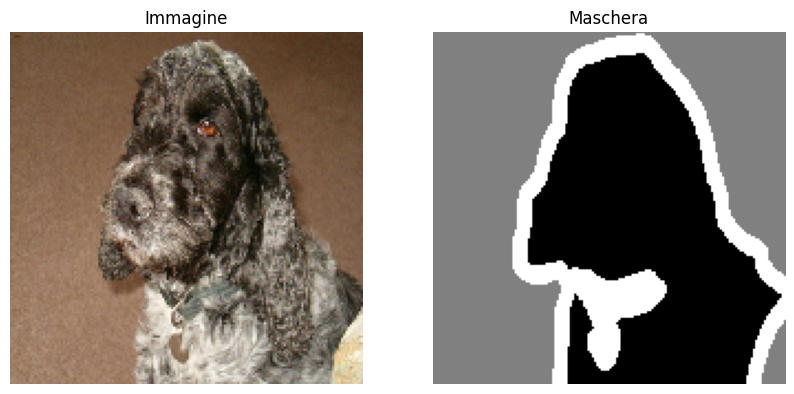

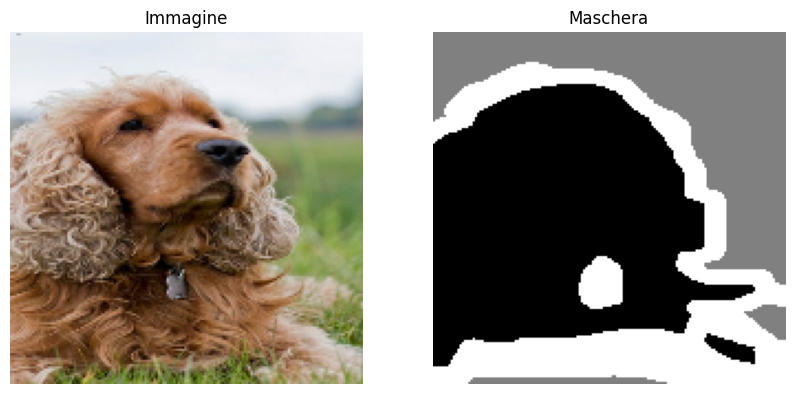

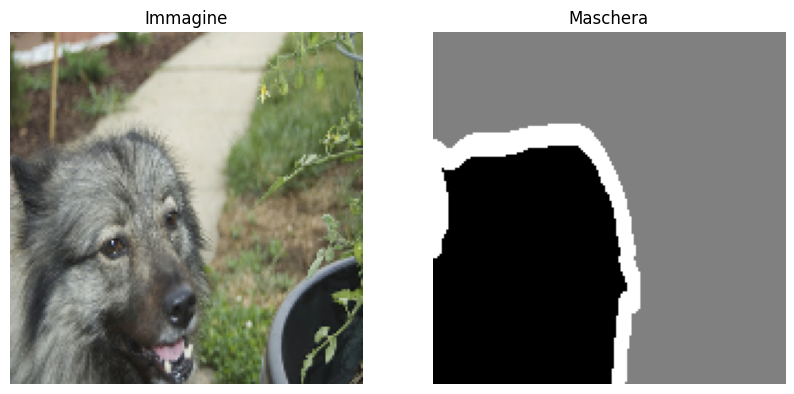

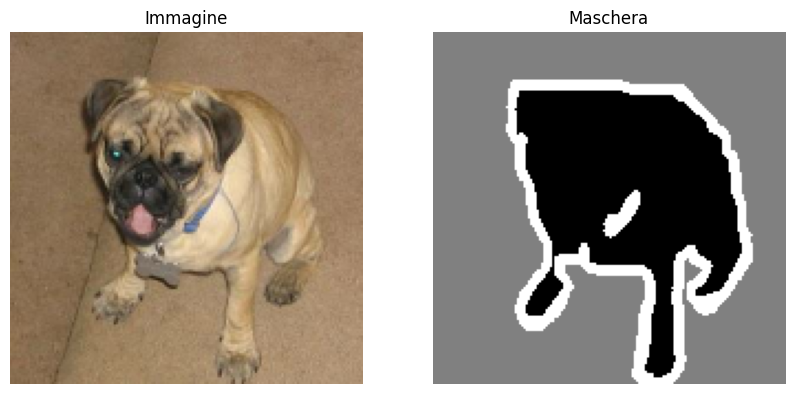

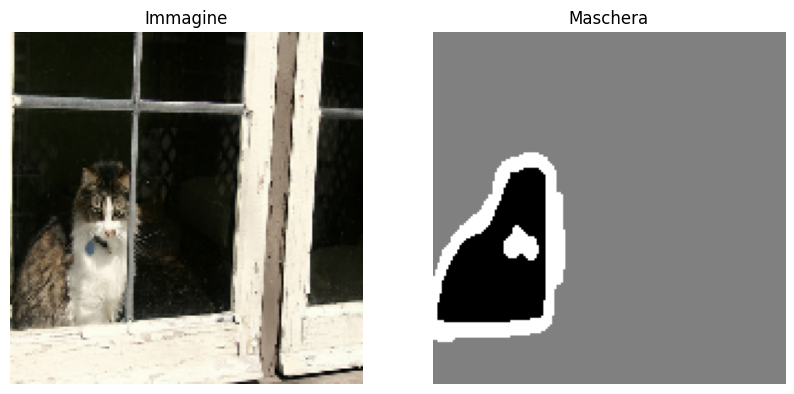

In [31]:
import matplotlib.pyplot as plt
for batch in train_dataset.take(1):  # Itera su un singolo batch
    images, masks = batch  # Scompone il batch in immagini e maschere

    print(f"Shape immagini: {images.shape}, Dtype: {images.dtype}")
    print(f"Shape maschere: {masks.shape}, Dtype: {masks.dtype}")

    # Visualizza le prime 5 immagini e relative maschere
    for i in range(5):
        plt.figure(figsize=(10, 5))

        # Immagine
        plt.subplot(1, 2, 1)
        plt.imshow((images[i].numpy()).astype("uint8"))
        plt.title("Immagine")
        plt.axis("off")

        # Maschera
        plt.subplot(1, 2, 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")  # Rimuovi dimensioni superflue
        plt.title("Maschera")
        plt.axis("off")

        plt.show()

Creiamo una callback che mostra lo stato di avanzamento del training alla fine di ogni epoch_interval.

Chiamiamo test-set un batch del trainig set su cui misurare i progressi nella callback.

In [32]:
# Taking a batch of test inputs to measure model's progress.
test_images, test_masks = next(iter(val_dataset))

class DisplayCallback(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            pred_masks = self.model.predict(test_images)
            pred_masks = tf.math.argmax(pred_masks, axis=-1)
            pred_masks = pred_masks[..., tf.newaxis] #aggiunge una nuova dimensione alla fine di pred_masks,
            # "..." è l'operatore di slicing ellittico, rappresenta tutte le dim non specificate.

            # Randomly select an image from the test batch
            random_index = random.randint(0, BATCH_SIZE - 1)
            random_image = test_images[random_index]
            random_pred_mask = pred_masks[random_index]
            random_true_mask = test_masks[random_index]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
            ax[0].imshow(random_image.numpy().astype("uint8"))
            ax[0].set_title(f"Image: {epoch:03d}")

            ax[1].imshow(random_true_mask)
            ax[1].set_title(f"Ground Truth Mask: {epoch:03d}")

            ax[2].imshow(random_pred_mask)
            ax[2].set_title(f"Predicted Mask: {epoch:03d}", )

            plt.show()
            plt.close()


callbacks = [DisplayCallback(4)]

# U-Net
La U-Net è un'architettura di rete convoluzionale pensata per la semantic segmentation. È composta da due parti principali:

**Encoder**: Riduce la dimensione spaziale dell'immagine, estraendo feature rilevanti tramite convoluzioni e pooling.

**Decoder**: Ricostruisce la dimensione originale, combinando upsampling e convoluzioni.

Un aspetto chiave della U-Net sono le **skip connections**, che collegano le feature map dell'encoder al decoder, permettendo di preservare dettagli spaziali fondamentali per una segmentazione accurata.

Progettata inizialmente per immagini biomediche, U-Net è oggi usata in molti contesti, come la guida autonoma e l'analisi di immagini satellitari, grazie alla sua capacità di segmentare accuratamente oggetti anche con dataset limitati.

![UNet](https://drive.google.com/uc?id=1UjsHXtPfb4ZeRzICpZJ-xcGZrusmqirv )


In [33]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate

def down_block(inputs, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(inputs)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    pool = MaxPooling2D(pool_size=(2, 2))(conv)
    return conv, pool

def up_block(inputs, skip, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    up = UpSampling2D(size=(2, 2))(inputs)
    concat = Concatenate()([up, skip])
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(concat)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    return conv


def unet(img_size=(256, 256, 1), num_classes=1):
    inputs = Input(shape=img_size + (3,))

    #Down Blocks
    conv1, pool1 = down_block(inputs, 64)
    conv2, pool2 = down_block(pool1, 128)
    conv3, pool3 = down_block(pool2, 256)

    # Bottleneck
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)

    #Up Blocks
    conv5 = up_block(conv4, conv3, 256)
    conv6 = up_block(conv5, conv2, 128)
    conv7 = up_block(conv6, conv1, 64)

    # Add a per-pixel classification layer
    outputs = keras.layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(conv7)

    model = Model(inputs=inputs, outputs=outputs, name="unet")
    return model



Instazia il modello

In [34]:
# Build model
model = unet(img_size=img_size, num_classes=NUM_CLASSES)
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 160, 160, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 160, 160, 64)   │          1,792 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 160, 160, 64)   │         36,928 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 80, 80, 64)     │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 80, 80, 128)    │         73,856 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 80, 80, 128)    │        147,584 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 40, 40, 128)    │              0 │ conv2d_4[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 40, 40, 256)    │        295,168 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 40, 40, 256)    │        590,080 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 20, 20, 256)    │              0 │ conv2d_6[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 20, 20, 512)    │      1,180,160 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 20, 20, 512)    │      2,359,808 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_1           │ (None, 40, 40, 512)    │              0 │ conv2d_8[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 40, 40, 768)    │              0 │ up_sampling2d_1[0][0], │
│                           │                        │                │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 40, 40, 256)    │      1,769,728 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 40, 40, 256)    │        590,080 │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_2      

 Total params: 7,784,579 (29.70 MB)

 Trainable params: 7,784,579 (29.70 MB)

 Non-trainable params: 0 (0.00 B)

Compila e allena

No weights loaded:
[Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/Colab_Images/Intro_AI_24-25//pesi_modello_v1.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5515 - loss: 13.6000

2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step


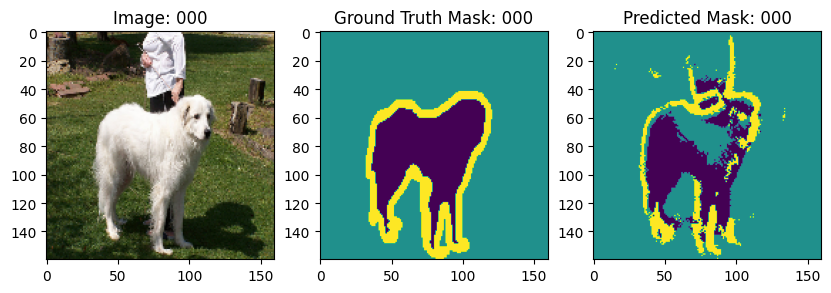

93/93 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.5524 - loss: 13.4975 - val_accuracy: 0.6944 - val_loss: 0.7407
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7236 - loss: 0.6917 - val_accuracy: 0.7528 - val_loss: 0.6201
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7641 - loss: 0.5910 - val_accuracy: 0.7699 - val_loss: 0.5744
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7909 - loss: 0.5266 - val_accuracy: 0.8001 - val_loss: 0.5121
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8116 - loss: 0.4788 - val_accuracy: 0.8139 - val_loss: 0.4822
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


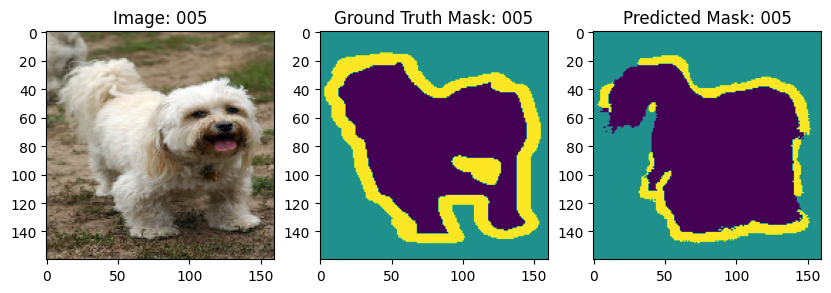

93/93 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8272 - loss: 0.4418 - val_accuracy: 0.8126 - val_loss: 0.4843
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8353 - loss: 0.4231 - val_accuracy: 0.8174 - val_loss: 0.4733
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8454 - loss: 0.3954 - val_accuracy: 0.8293 - val_loss: 0.4426
Epoch 9/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8539 - loss: 0.3757 - val_accuracy: 0.8421 - val_loss: 0.4171
Epoch 10/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8610 - loss: 0.3583 - val_accuracy: 0.8416 - val_loss: 0.4293


In [35]:
model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

try:
    model.load_weights(save_path + '/pesi_modello_v1.weights.h5')
    EPOCHS=0
    print("Pesi modello caricati")
except Exception as e:
    print(f"No weights loaded:\n{e}")


# Train the model, doing validation at the end of each epoch.
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Sovrascrivo i pesi.

In [36]:
model.save_weights(save_path + '/pesi_modello.weights.h5')

Esempio di predizione su alcune immagini dopo che la rete è stata allenata.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


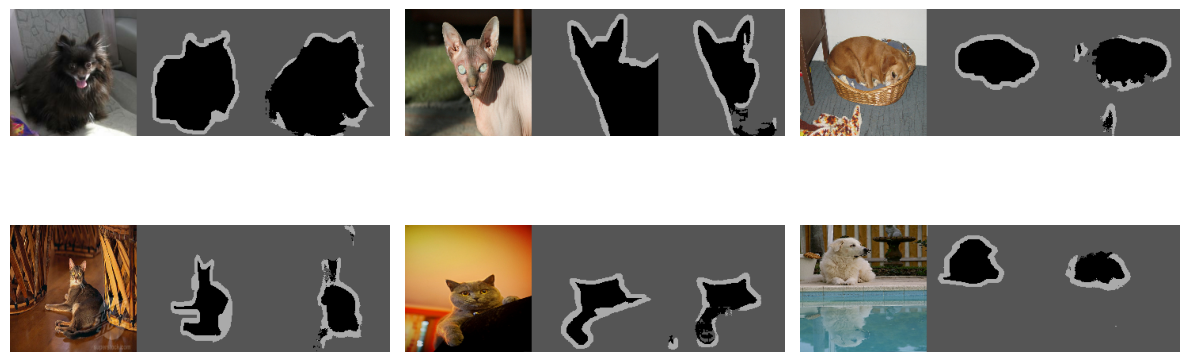

In [37]:
model.load_weights(save_path + '/pesi_modello.weights.h5')

pred_masks = model.predict(test_images)
pred_masks = tf.math.argmax(pred_masks, axis=-1)[..., None]

keras_cv.visualization.plot_segmentation_mask_gallery(
    test_images.numpy().astype("uint8"),
    value_range=(0, 255),
    num_classes=3,
    y_true=test_masks,
    y_pred=pred_masks,
    scale=4,
    rows=2,
    cols=3,
)

Esempio completo a questo link:
https://keras.io/examples/vision/oxford_pets_image_segmentation/#prediction-with-trained-model

